C:\Users\Mark1\AppData\Local\Temp\ipykernel_6696\2278052718.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(days, np.ones(time_steps) * initial_pressure, 'r--', label='Steady Pressure', color='r')


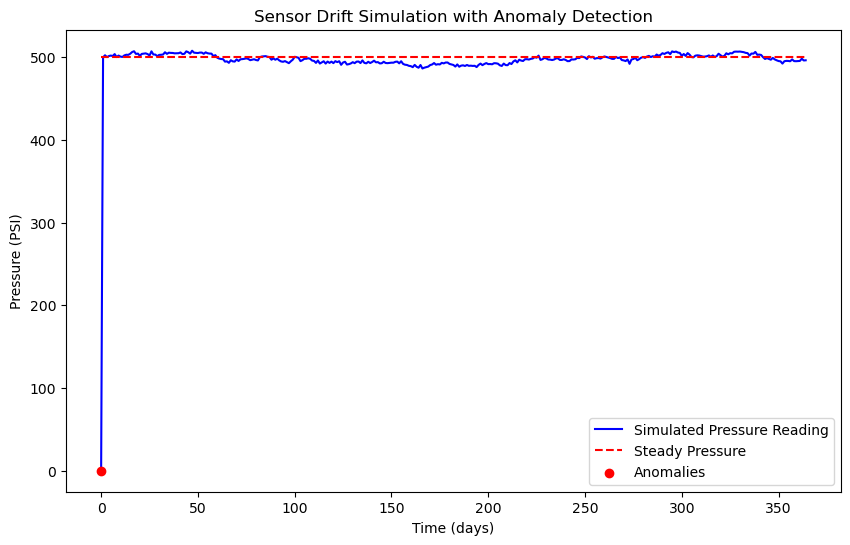

Number of anomalies detected: 1


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
full_scale_range = 1000  # in PSI
long_term_drift = 0.001 * full_scale_range  # in PSI per day
steady_pressure = 500  # in PSI
time_steps = 365  # number of days to simulate
anomaly_threshold = 15  # in PSI

# Initialize variables
days = np.arange(time_steps)
initial_pressure = steady_pressure
pressure = np.zeros(time_steps)
drift = np.zeros(time_steps)

# Simulate sensor drift
for t in range(1, time_steps):
    # Apply drift
    drift[t] = drift[t - 1] + np.random.normal(0, long_term_drift)
    # Simulate sensor reading
    pressure[t] = initial_pressure + drift[t] + np.random.normal(0, 1)  # Add some noise

# Detect anomalies
anomalies = np.abs(pressure - initial_pressure) > anomaly_threshold
num_anomalies = np.sum(anomalies)

# Plot the simulated pressure reading over time
plt.figure(figsize=(10, 6))
plt.plot(days, pressure, label='Simulated Pressure Reading', color='b')
plt.plot(days, np.ones(time_steps) * initial_pressure, 'r--', label='Steady Pressure', color='r')
plt.scatter(days[anomalies], pressure[anomalies], color='r', label='Anomalies', zorder=5)
plt.xlabel('Time (days)')
plt.ylabel('Pressure (PSI)')
plt.title('Sensor Drift Simulation with Anomaly Detection')
plt.legend()
plt.show()

# Print the number of anomalies detected
print(f"Number of anomalies detected: {num_anomalies}")
